In [2]:
# Import the Libraries for Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the Myntra Sales Dataset for into dataframe
df = pd.read_csv('/content/Amazon Sale Report.csv', engine='python')
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [5]:

df.shape

(107601, 24)

In [6]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107601 entries, 0 to 107600
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               107601 non-null  int64  
 1   Order ID            107601 non-null  object 
 2   Date                107601 non-null  object 
 3   Status              107601 non-null  object 
 4   Fulfilment          107601 non-null  object 
 5   Sales Channel       107601 non-null  object 
 6   ship-service-level  107601 non-null  object 
 7   Style               107601 non-null  object 
 8   SKU                 107601 non-null  object 
 9   Category            107601 non-null  object 
 10  Size                107601 non-null  object 
 11  ASIN                107601 non-null  object 
 12  Courier Status      101656 non-null  object 
 13  Qty                 107600 non-null  float64
 14  currency            101093 non-null  object 
 15  Amount              101093 non-nul

In [7]:
# Describe the data using descriptive Statistics
df.describe()

,index,Qty,Amount,ship-postal-code
count,107601.000000,107600.000000,101093.000000,107573.000000
mean,53800.000000,0.902890,646.110753,463594.707203
std,31061.877495,0.316116,279.948113,192407.604664
min,0.000000,0.000000,0.000000,110001.000000
25%,26900.000000,1.000000,446.000000,380061.000000
50%,53800.000000,1.000000,599.000000,500029.000000
75%,80700.000000,1.000000,788.000000,600028.000000
max,107600.000000,15.000000,5584.000000,989898.000000


In [8]:
# Handling the missing data
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [9]:
# Check the duplicates values from the dataset
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
107596,False
107597,False
107598,False
107599,False


In [10]:
# Remove the duplicate values from the dataset
df.drop_duplicates().reset_index(drop=True)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107596,107596,402-0543691-8989132,06-15-22,Shipped,Amazon,Amazon.in,Expedited,J0381,J0381-SKD-L,Set,...,INR,1234.00,HYDERABAD,TELANGANA,500074.0,IN,NaN,False,NaN,False
107597,107597,402-7721041-0509900,06-15-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET392,SET392-KR-NP-XXL,Set,...,INR,799.00,PUNE,MAHARASHTRA,411040.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
107598,107598,402-0901599-3540304,06-15-22,Shipped,Amazon,Amazon.in,Expedited,SET396,SET396-KR-PP-XL,Set,...,INR,988.00,PUNE,MAHARASHTRA,411040.0,IN,NaN,False,NaN,False
107599,107599,405-7487844-5288344,06-15-22,Cancelled,Amazon,Amazon.in,Expedited,JNE3749,JNE3749-KR-XS,kurta,...,NaN,NaN,KURNOOL,ANDHRA PRADESH,518006.0,IN,NaN,False,NaN,False


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
Discount_Percent = df['discount_percent'].clip(upper= 1.0)
Discount_Percent.head()

KeyError: 'discount_percent'

In [13]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [15]:
df['Status'].value_counts()[:10]

,count
Status,
Shipped,63740
Shipped - Delivered to Buyer,24792
Cancelled,15321
Shipped - Returned to Seller,1664
Shipped - Picked Up,964
Pending,657
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,133
Shipped - Out for Delivery,32


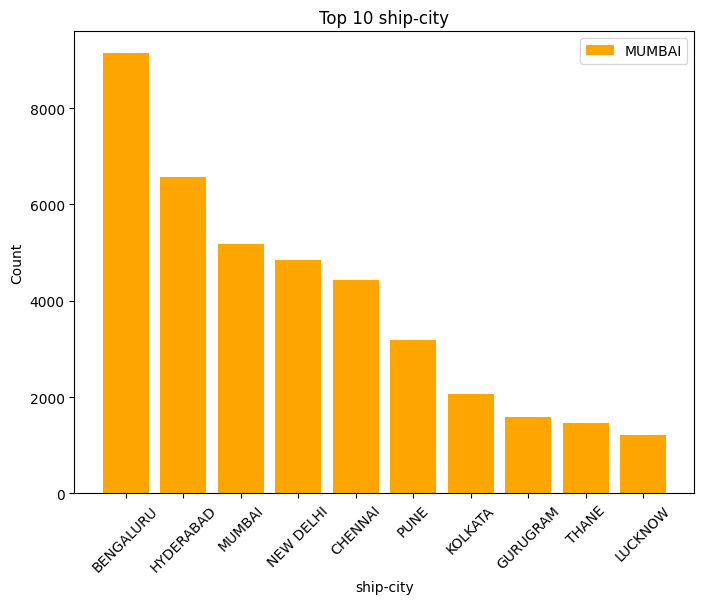

In [17]:
city = df['ship-city'].value_counts().reset_index().sort_values(by = 'count', ascending = False)[:10]
plt.figure(figsize=(8,6))
plt.bar(city['ship-city'], city['count'], color='orange')
plt.xlabel('ship-city')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.title('Top 10 ship-city')
plt.legend(df['ship-city'])
plt.show()

In [22]:
Avg_Amount = df['Amount'].mean()
print(Avg_Amount)

646.110753266794


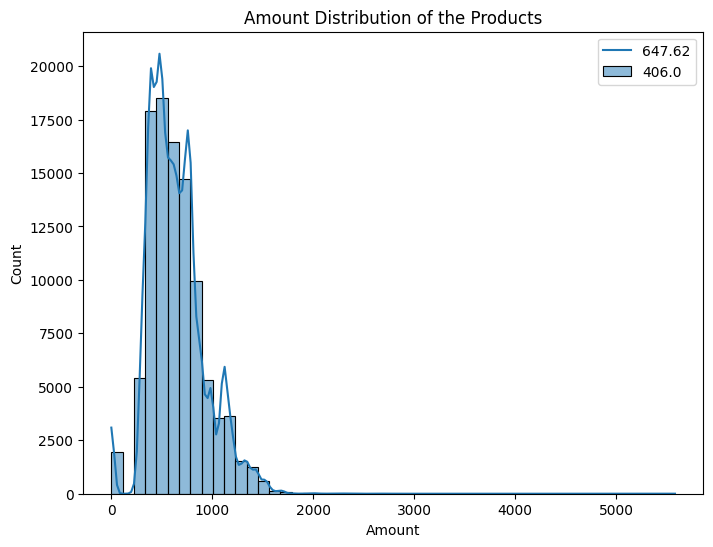

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df['Amount'], bins = 50, kde=True)
plt.title("Amount Distribution of the Products")
plt.legend(df['Amount'])
plt.show()

/tmp/ipykernel_746/395153666.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Status', order=df['Status'].value_counts().index, palette='viridis')


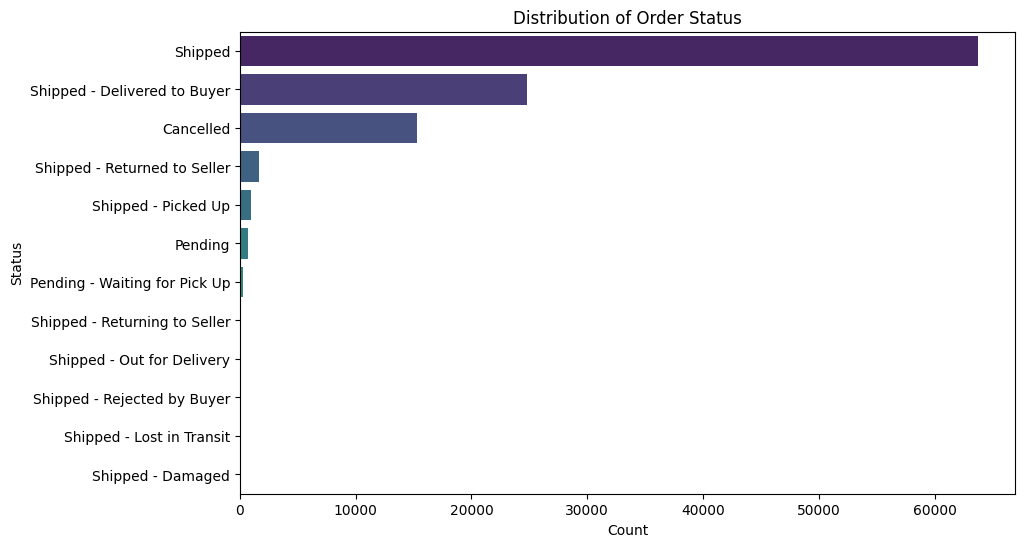

In [19]:
# Plot the distribution of 'Status'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Status', order=df['Status'].value_counts().index, palette='viridis')
plt.title('Distribution of Order Status')
plt.xlabel('Count')
plt.ylabel('Status')
plt.show()

In [25]:
ship_service_level = df['ship-service-level'].value_counts()[:10].reset_index().sort_values(by='count', ascending=False)
print(ship_service_level)

  ship-service-level  count
0          Expedited  72654
1           Standard  34947


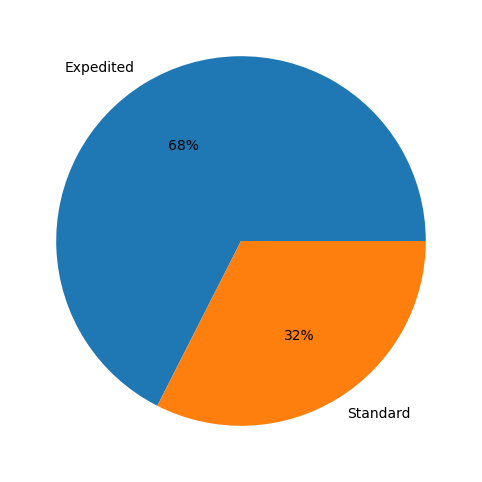

In [27]:
plt.figure(figsize=(8,6))
plt.pie(ship_service_level['count'][:10], labels = ship_service_level['ship-service-level'][:10], autopct = '%.0f%%')
plt.show()

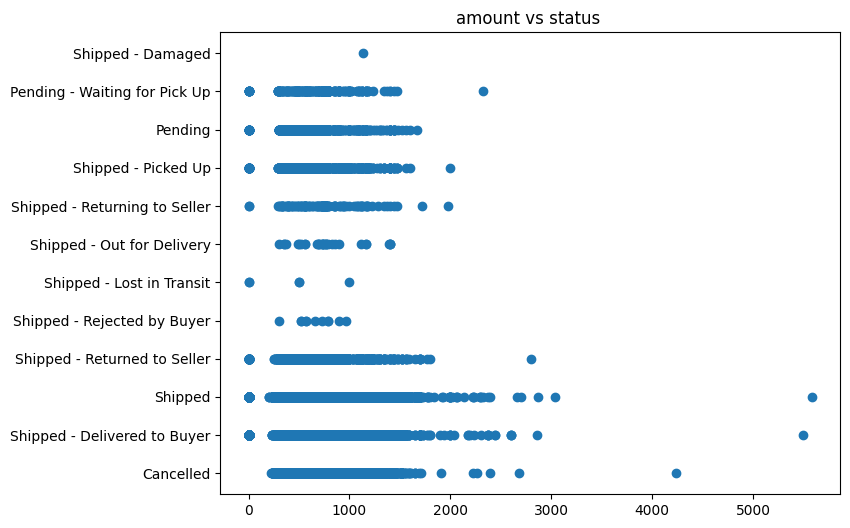

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(x=df['Amount'], y=df['Status'])
plt.title("amount vs status ")
plt.show()